removing urls

In [1]:
import pandas as pd   # for data manupulating
import re # for regular expressions
from pprint import pprint
from bs4 import BeautifulSoup # webscape
from tqdm import tqdm  # progress bar
import nltk

from nltk.stem import PorterStemmer, WordNetLemmatizer

In [2]:
nltk.download("stopwords")
nltk.download('wordnet') # lemmatiztion
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))
print(stopwords)

{'no', 'do', 'having', 'their', 'haven', 'other', 'our', 'but', 'hadn', 'yourselves', 'ourselves', 'against', 'each', 'or', 'doesn', 'here', "i'd", 'needn', 'own', 'his', 'such', "we're", 'just', 'she', 'any', 'ours', "hasn't", 'below', 'are', 'was', "he's", 'shouldn', 'too', 'with', 'shan', 'd', 'which', 'does', 'have', 'did', "he'll", 'if', 'where', "that'll", 'be', "hadn't", 'of', 'you', 'mightn', 'herself', 'a', 'out', 'that', 'over', "weren't", 'all', 'he', 'now', 'themselves', 'some', 'to', "wasn't", 'above', 'i', 'not', 'hers', "you've", 'an', 'm', 'again', 'them', 't', 'doing', 'further', 'same', 'at', 'had', 'how', "needn't", 'theirs', 'why', 'up', 'won', 'mustn', 'under', 'isn', 'wouldn', 'me', "couldn't", 'who', "don't", "it's", 'then', 'itself', 'and', "should've", "we've", 'when', "we'd", 'in', 'weren', 'because', "doesn't", 'we', 'will', 'it', "you'd", 'being', 'after', 'nor', 's', "we'll", 'didn', 'more', 'only', 'am', 'through', 'from', "i'm", 'down', 'your', "she's", '

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("./reviews_clean_file", index_col=0)

In [4]:
def remove_tags(sent):
    soup = BeautifulSoup(sent,'html.parser')
    text = soup.get_text(" ",strip=True)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)   # still any plain urls
    return text

Removing special symbols 
i've => i have

In [5]:
def decontracted(phrase):
    phrase = re.sub(r"won\'t", "will not", phrase)  # sub => substitute
    phrase = re.sub(r"can\'t", "can not", phrase)   # r"" => pattern matching
 
    phrase = re.sub(r"\'ve"," have",phrase)
    phrase = re.sub(r"\'s", " is", phrase)   # it's => it is , (exception shiva's book => shiva is book) => nlp problem
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'d", " would",phrase)
    phrase = re.sub(r"o\'clock","of the clock",phrase)
    phrase = re.sub(r"\'ll"," will",phrase)
    phrase = re.sub(r"\'re", " are",phrase)
    phrase = re.sub(r"\'m"," am", phrase)

    return phrase

combining above everything for whole dataset    

In [6]:
preprocessed_reviews = []
stemmed_reviews = []
lemmatized_reviews = []


stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

for sent in tqdm(df['Text'].values):
    sent = remove_tags(sent) # remove the tags, urls
    sent = decontracted(sent)
    sent = re.sub(r"\S*\d\S*","",sent).strip()  # "ABC123" => ""
    sent = re.sub(r"[^A-Za-z]+"," ",sent)

    res = " ".join( word.lower() for word in sent.split() if word.lower() not in stopwords)
    preprocessed_reviews.append(res)

    #stemming
    stemmed = " ".join(stemmer.stem(word) for word in res.split())
    stemmed_reviews.append(stemmed)

    #lemmatization
    lemmatized = " ".join(lemmatizer.lemmatize(word) for word in res.split())
    lemmatized_reviews.append(lemmatized)

 84%|████████▍ | 307293/365331 [08:43<01:03, 910.38it/s] C:\Users\shiva\AppData\Local\Temp\ipykernel_28232\3668874809.py:2: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  soup = BeautifulSoup(sent,'html.

In [7]:
# %pip install wordcloud

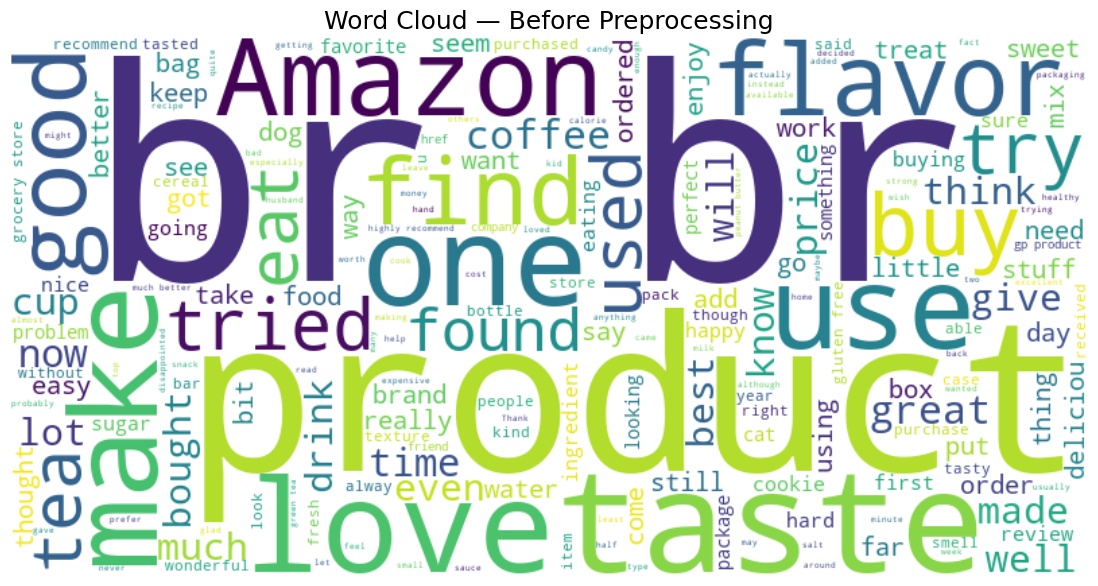

In [8]:
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

#BEFORE PREPROCESSING
text_before = " ".join(review for review in df['Text'])
wordcloud_before = WordCloud(width=800, height=400, background_color='white',
                             stopwords=STOPWORDS, max_words=200, colormap='viridis').generate(text_before)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud — Before Preprocessing", fontsize=18)
plt.show()

saving and creating preprossed csv file

In [9]:
df['CleanedText'] = preprocessed_reviews
df["StemmedText"] = stemmed_reviews
df["LemmatizedText"] = lemmatized_reviews

In [10]:
df.to_csv("preprocessed_reviews.csv", index=False)

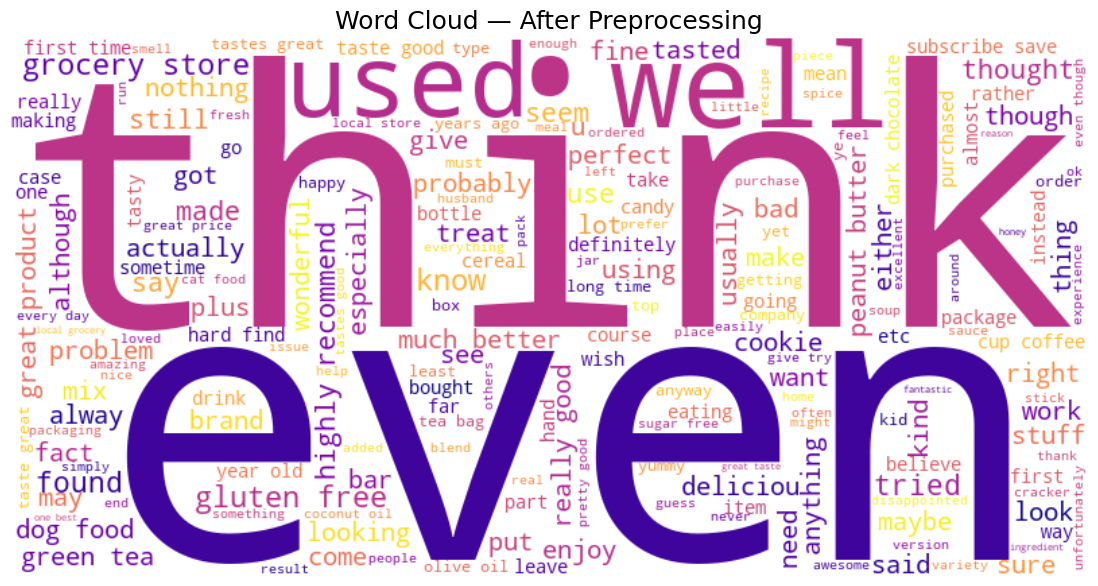

In [11]:
#  AFTER PREPROCESSING
# join all preprocessed reviews
text_after = " ".join(review for review in preprocessed_reviews)
wordcloud_after = WordCloud(width=800, height=400, background_color='white',
                            stopwords=STOPWORDS, max_words=200, colormap='plasma').generate(text_after)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud — After Preprocessing", fontsize=18)
plt.show()

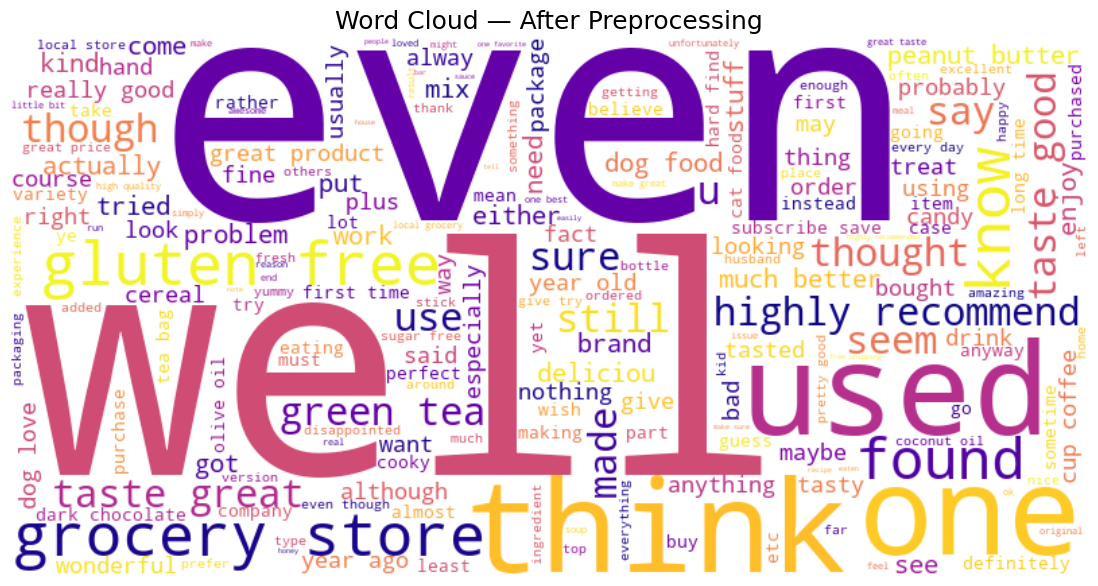

In [ ]:
#  AFTER PREPROCESSING
# join all lemmatized reviews
text_after = " ".join(review for review in lemmatized_reviews)
wordcloud_after = WordCloud(width=800, height=400, background_color='white',
                            stopwords=STOPWORDS, max_words=200, colormap='plasma').generate(text_after)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud — After Preprocessing", fontsize=18)
plt.show()